In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

%matplotlib notebook

In [2]:
from particle_filter import *

In [3]:

def make_normal_dist_positive_fn(mean, std):
    def normal_distribution_fn(num):
        return np.clip(std * np.random.randn(num) + mean, 0, np.inf)
    return normal_distribution_fn

In [4]:
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
from celluloid import Camera

0.025 pi-ov-12


<IPython.core.display.Javascript object>


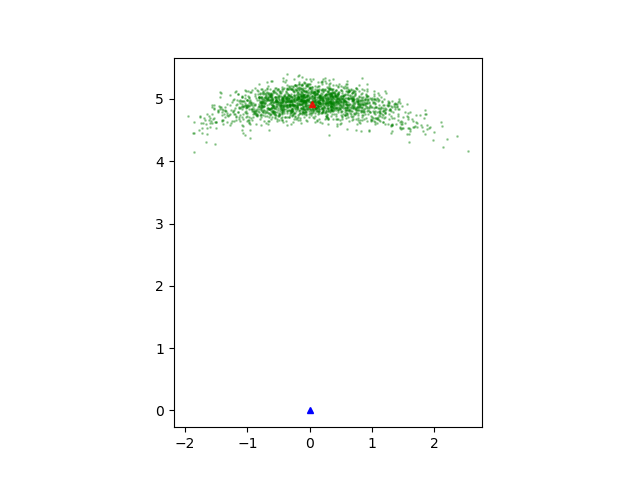

0.025 pi-ov-6


<IPython.core.display.Javascript object>


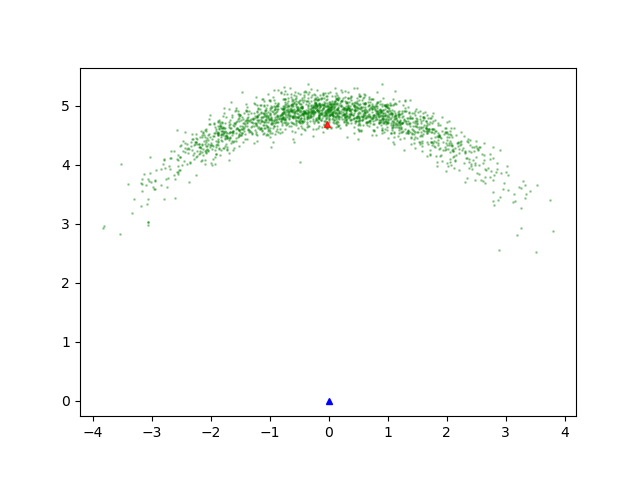

0.025 pi-ov-4


<IPython.core.display.Javascript object>


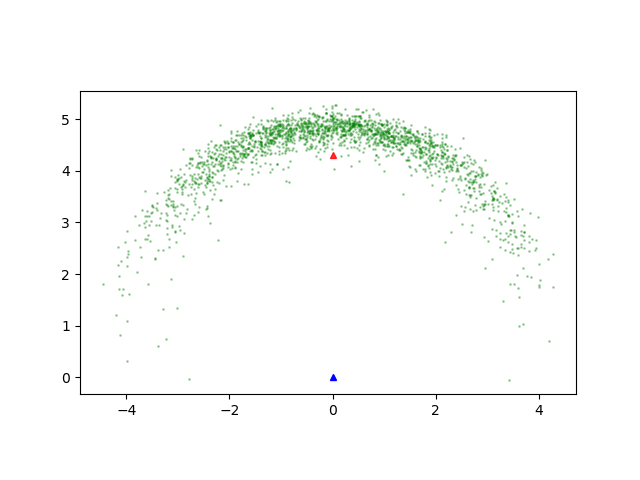

0.025 pi-ov-3


<IPython.core.display.Javascript object>


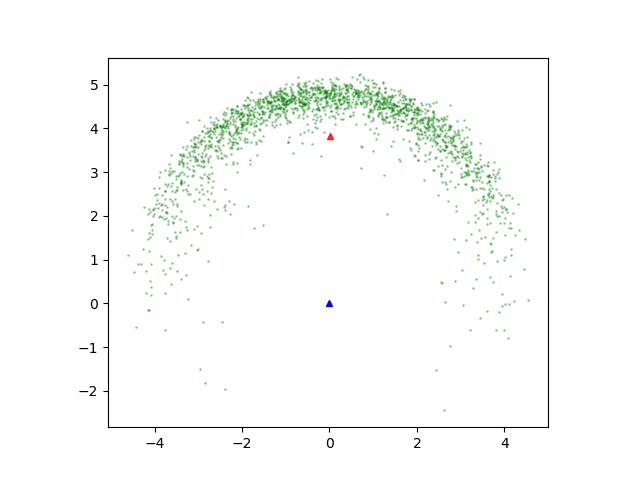

0.05 pi-ov-12


<IPython.core.display.Javascript object>


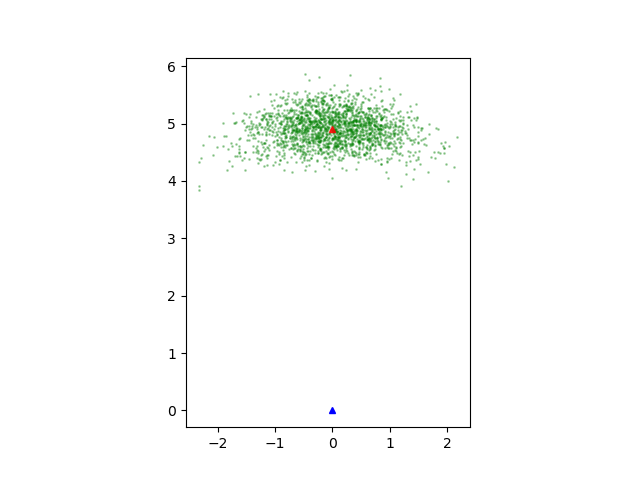

0.05 pi-ov-6


<IPython.core.display.Javascript object>


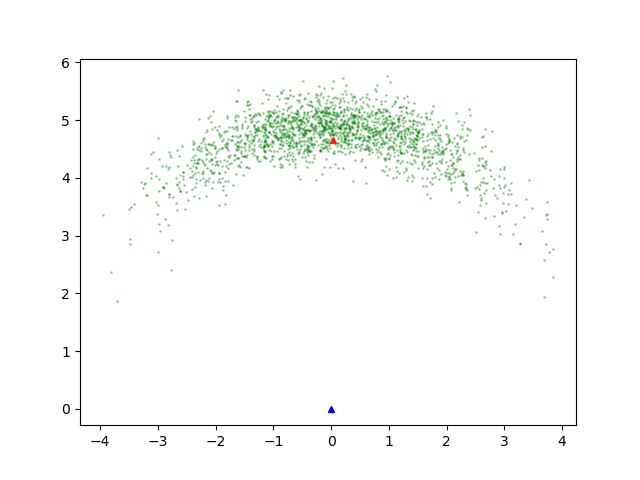

0.05 pi-ov-4


<IPython.core.display.Javascript object>


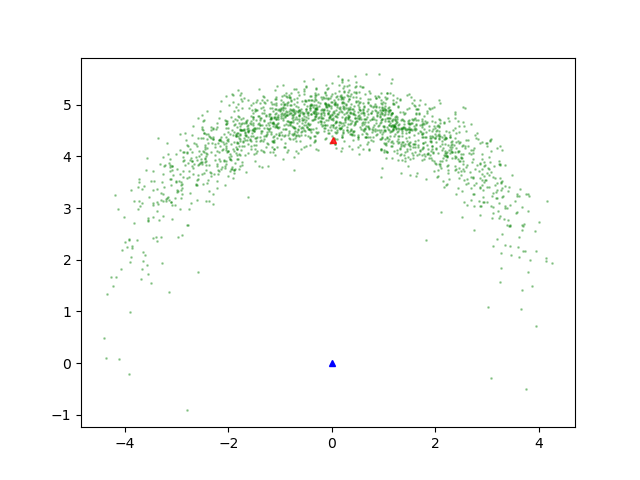

0.05 pi-ov-3


<IPython.core.display.Javascript object>


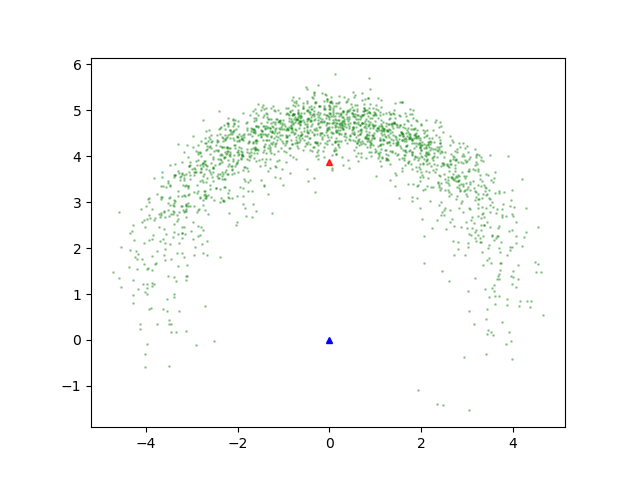

0.1 pi-ov-12


<IPython.core.display.Javascript object>


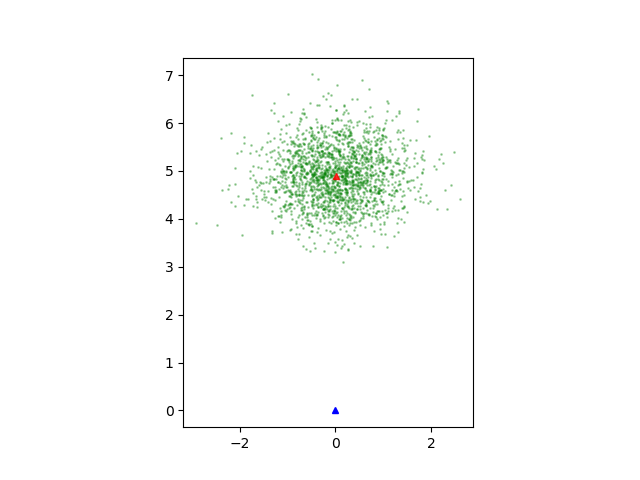

0.1 pi-ov-6


<IPython.core.display.Javascript object>


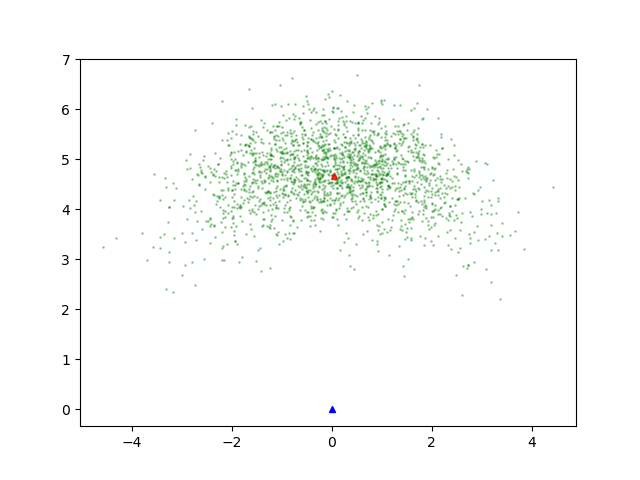

0.1 pi-ov-4


<IPython.core.display.Javascript object>


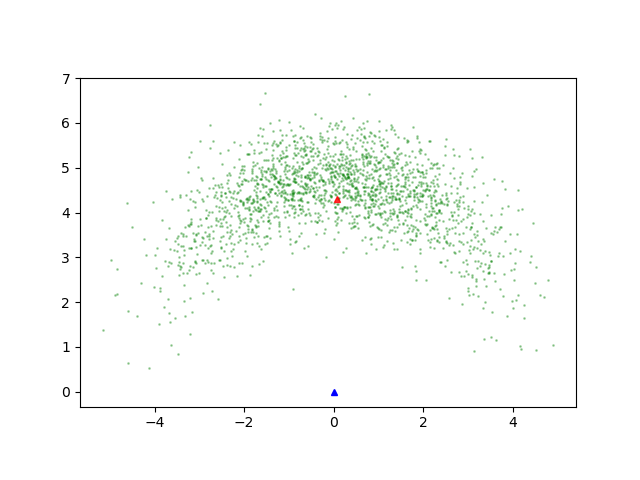

0.1 pi-ov-3


<IPython.core.display.Javascript object>


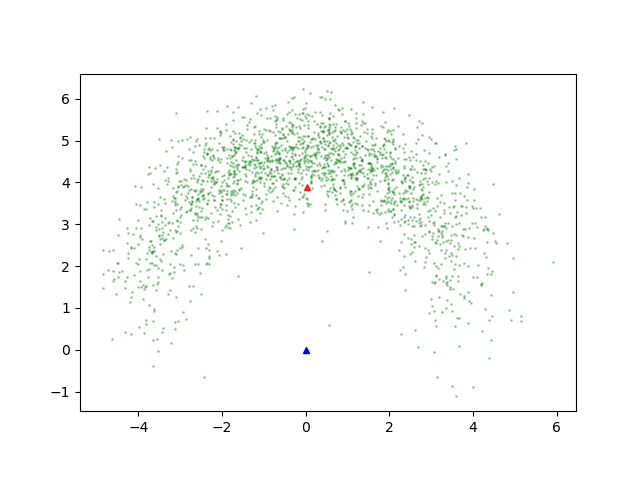

0.5 pi-ov-12


<IPython.core.display.Javascript object>


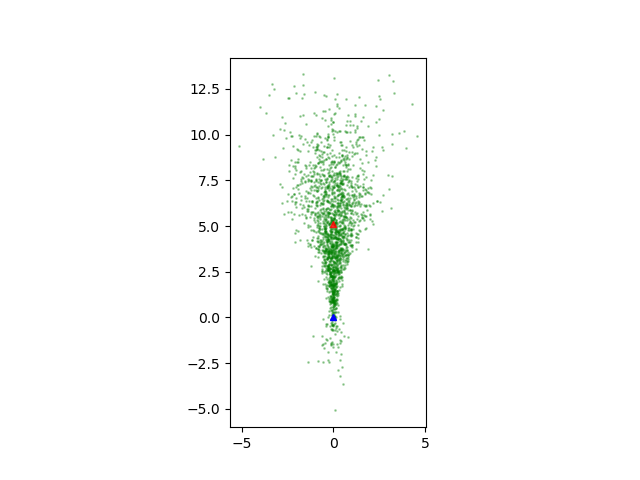

0.5 pi-ov-6


<IPython.core.display.Javascript object>


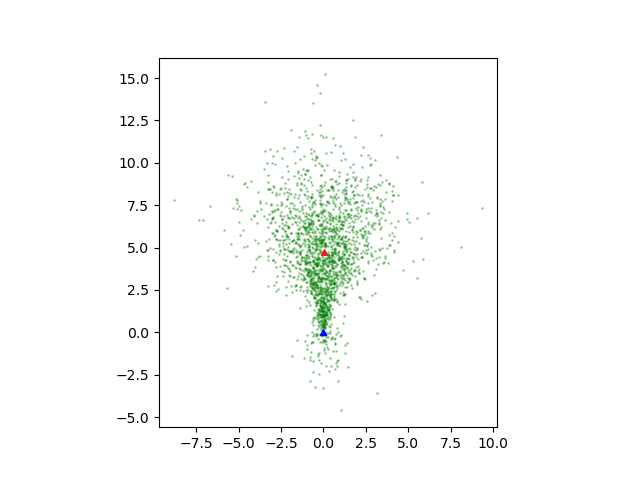

0.5 pi-ov-4


<IPython.core.display.Javascript object>


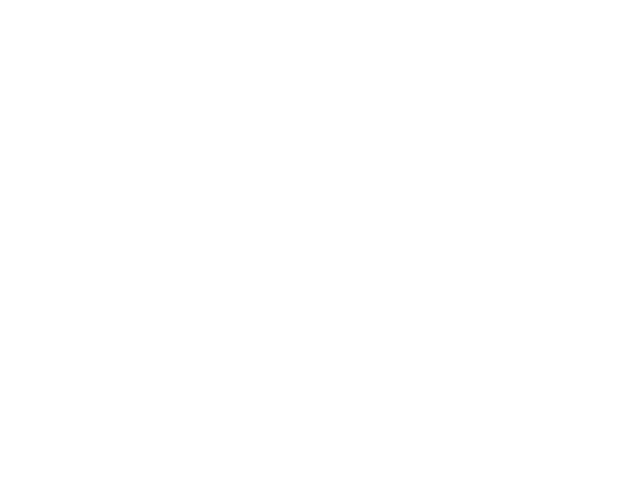

0.5 pi-ov-3


<IPython.core.display.Javascript object>


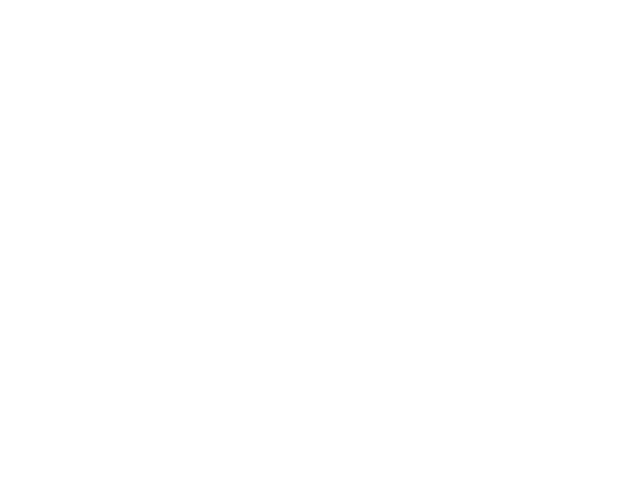

1.0 pi-ov-12


<IPython.core.display.Javascript object>


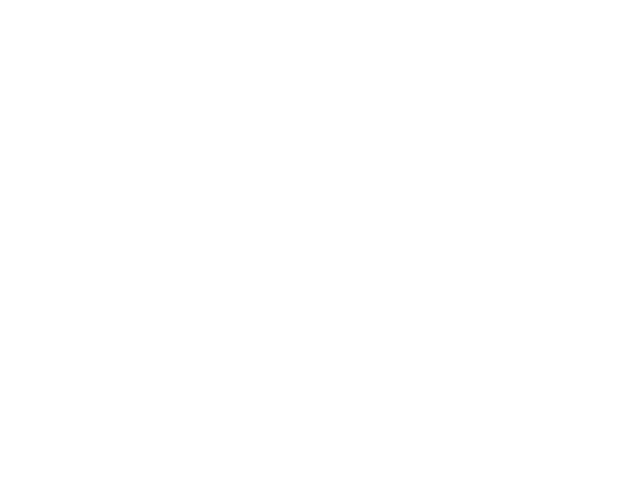

1.0 pi-ov-6


<IPython.core.display.Javascript object>


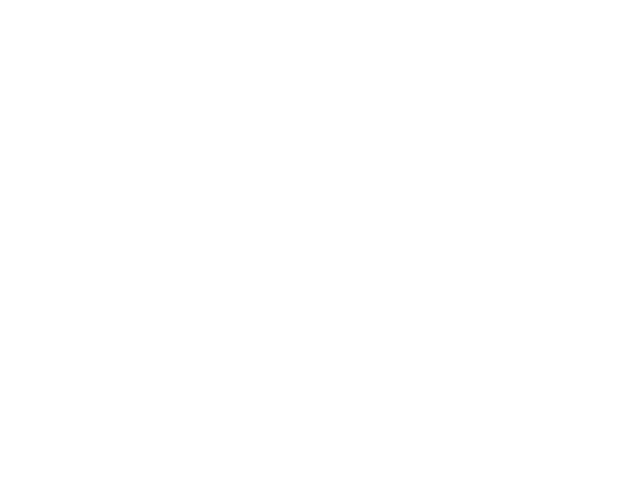

1.0 pi-ov-4


<IPython.core.display.Javascript object>


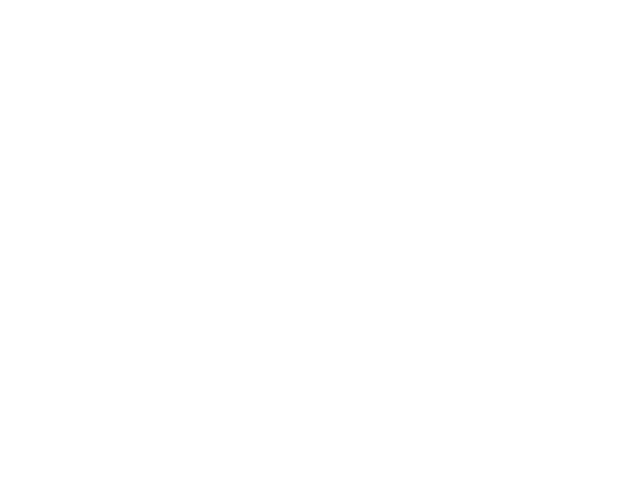

1.0 pi-ov-3


<IPython.core.display.Javascript object>


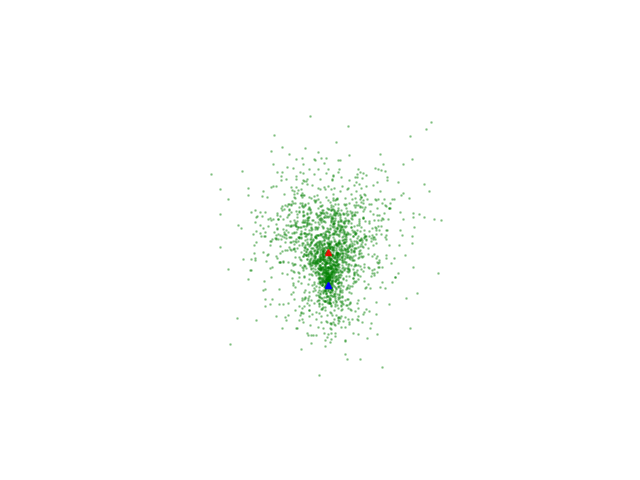

In [5]:
import itertools

a_ranges = [0.025, 0.05, 0.1, 0.5, 1.0]
omega_ranges = [np.pi/12, np.pi/6, np.pi/4, np.pi/3]

names = {
    np.pi/12: "pi-ov-12",
    np.pi/8: "pi-ov-8",
    np.pi/6: "pi-ov-6",
    np.pi/4: "pi-ov-4",
    np.pi/3: "pi-ov-3",
}

for a, omega in itertools.product(a_ranges, omega_ranges):
    print(a, names[omega])
    fig, ax = plt.subplots()
    ax.set_aspect('equal', 'box')

    init_state = np.array([0,0,0.5,np.pi/2])

    pf = ParticleFilter(
        init_state=init_state, 
        init_state_covariance=None,
        acceleration_sampler = make_normal_distribution_fn(0, a),
        angular_acceleration_sampler=make_normal_distribution_fn(0, omega),
        num_particles=2000
    )
    points = pf.particles[:, [0, 1]].T
    colors = cm.rainbow(np.linspace(0, 1, len(points[0])))
    camera = Camera(fig)
    for _ in range(100):
        pf.propagate(0.1)
        points = pf.particles[:, [0, 1]].T
        startx, starty = init_state[0], init_state[1]
        plt.plot(startx, starty, c='b', marker="^", markersize=5)

    #     std = np.std(pf.particles[:, :2], axis=0)
    #     confidence = min(1, 1 / np.linalg.norm(std))
        plt.plot(pf.expected_state[0], pf.expected_state[1], c='r', marker="^", markersize=5, alpha=0.8)
        ax.scatter(*points, c="green", s=1, alpha=0.3)
        camera.snap()
    anim = camera.animate(blit=True)
    anim.save(f'a-sigma={a}_omega-sigma={names[omega]}.mp4')